### Introduction to Transformer architecture
* what is a transformer?
    * neural network architecture introduced in the paper "Attention is All you need"
    * it relies entirly on the attention mecahnism to process sequential data without using recurrence or convolution
    * transformative for NLP tasks like translation summarization , and text generation
* Components of Transformer
    * Encoder
        * Process the input sequence and ge4enerates a contextuialized represntation
        * Consistes of multiple idnetical layers each with 
            * self-attention mechanism: Captures dependencies between all input tokens
            * Feed -Forward Neural Network (FFN): Processes the attention outputs
    * Deocder
        * generates the oputput sequence one token at atime
        * Consists of multiple identical layers,each with
            * masked self0attention mechanism: prevents the decoder from attending to future tokens
            * Encoder - Decoder attention : attends to encoder output
            * Feed-Forward Neural Network
    * Workflow: Input sequence -> Encoder --> Context Vectors --> Decoder --> Output sequence

### Detailed breakdown of the transformer model layers
* self-Attention Layer
    * Captures relationship between all tokens in the input sequence
    * Computes the importnace of each token to all the other tokens
* Postional Encoding
    * Since transformers lack recurrence , positional  encoding injects information about the token order into the model
* Feed Forward Neural Network
    * Applies a position -wise FFNN to the outputs of the attention layer
    * Non- linear transformation enhances the represntation
* Layer Normalization
    * Stabilizes training by normalizing within each layer
* Multi-Head Attention
    * Combines Multiple self-attention mechanisms to learn various aspects of relationships within the sequence



In [1]:
# Visualizing transformers
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LayerNormalization, Add, MultiHeadAttention

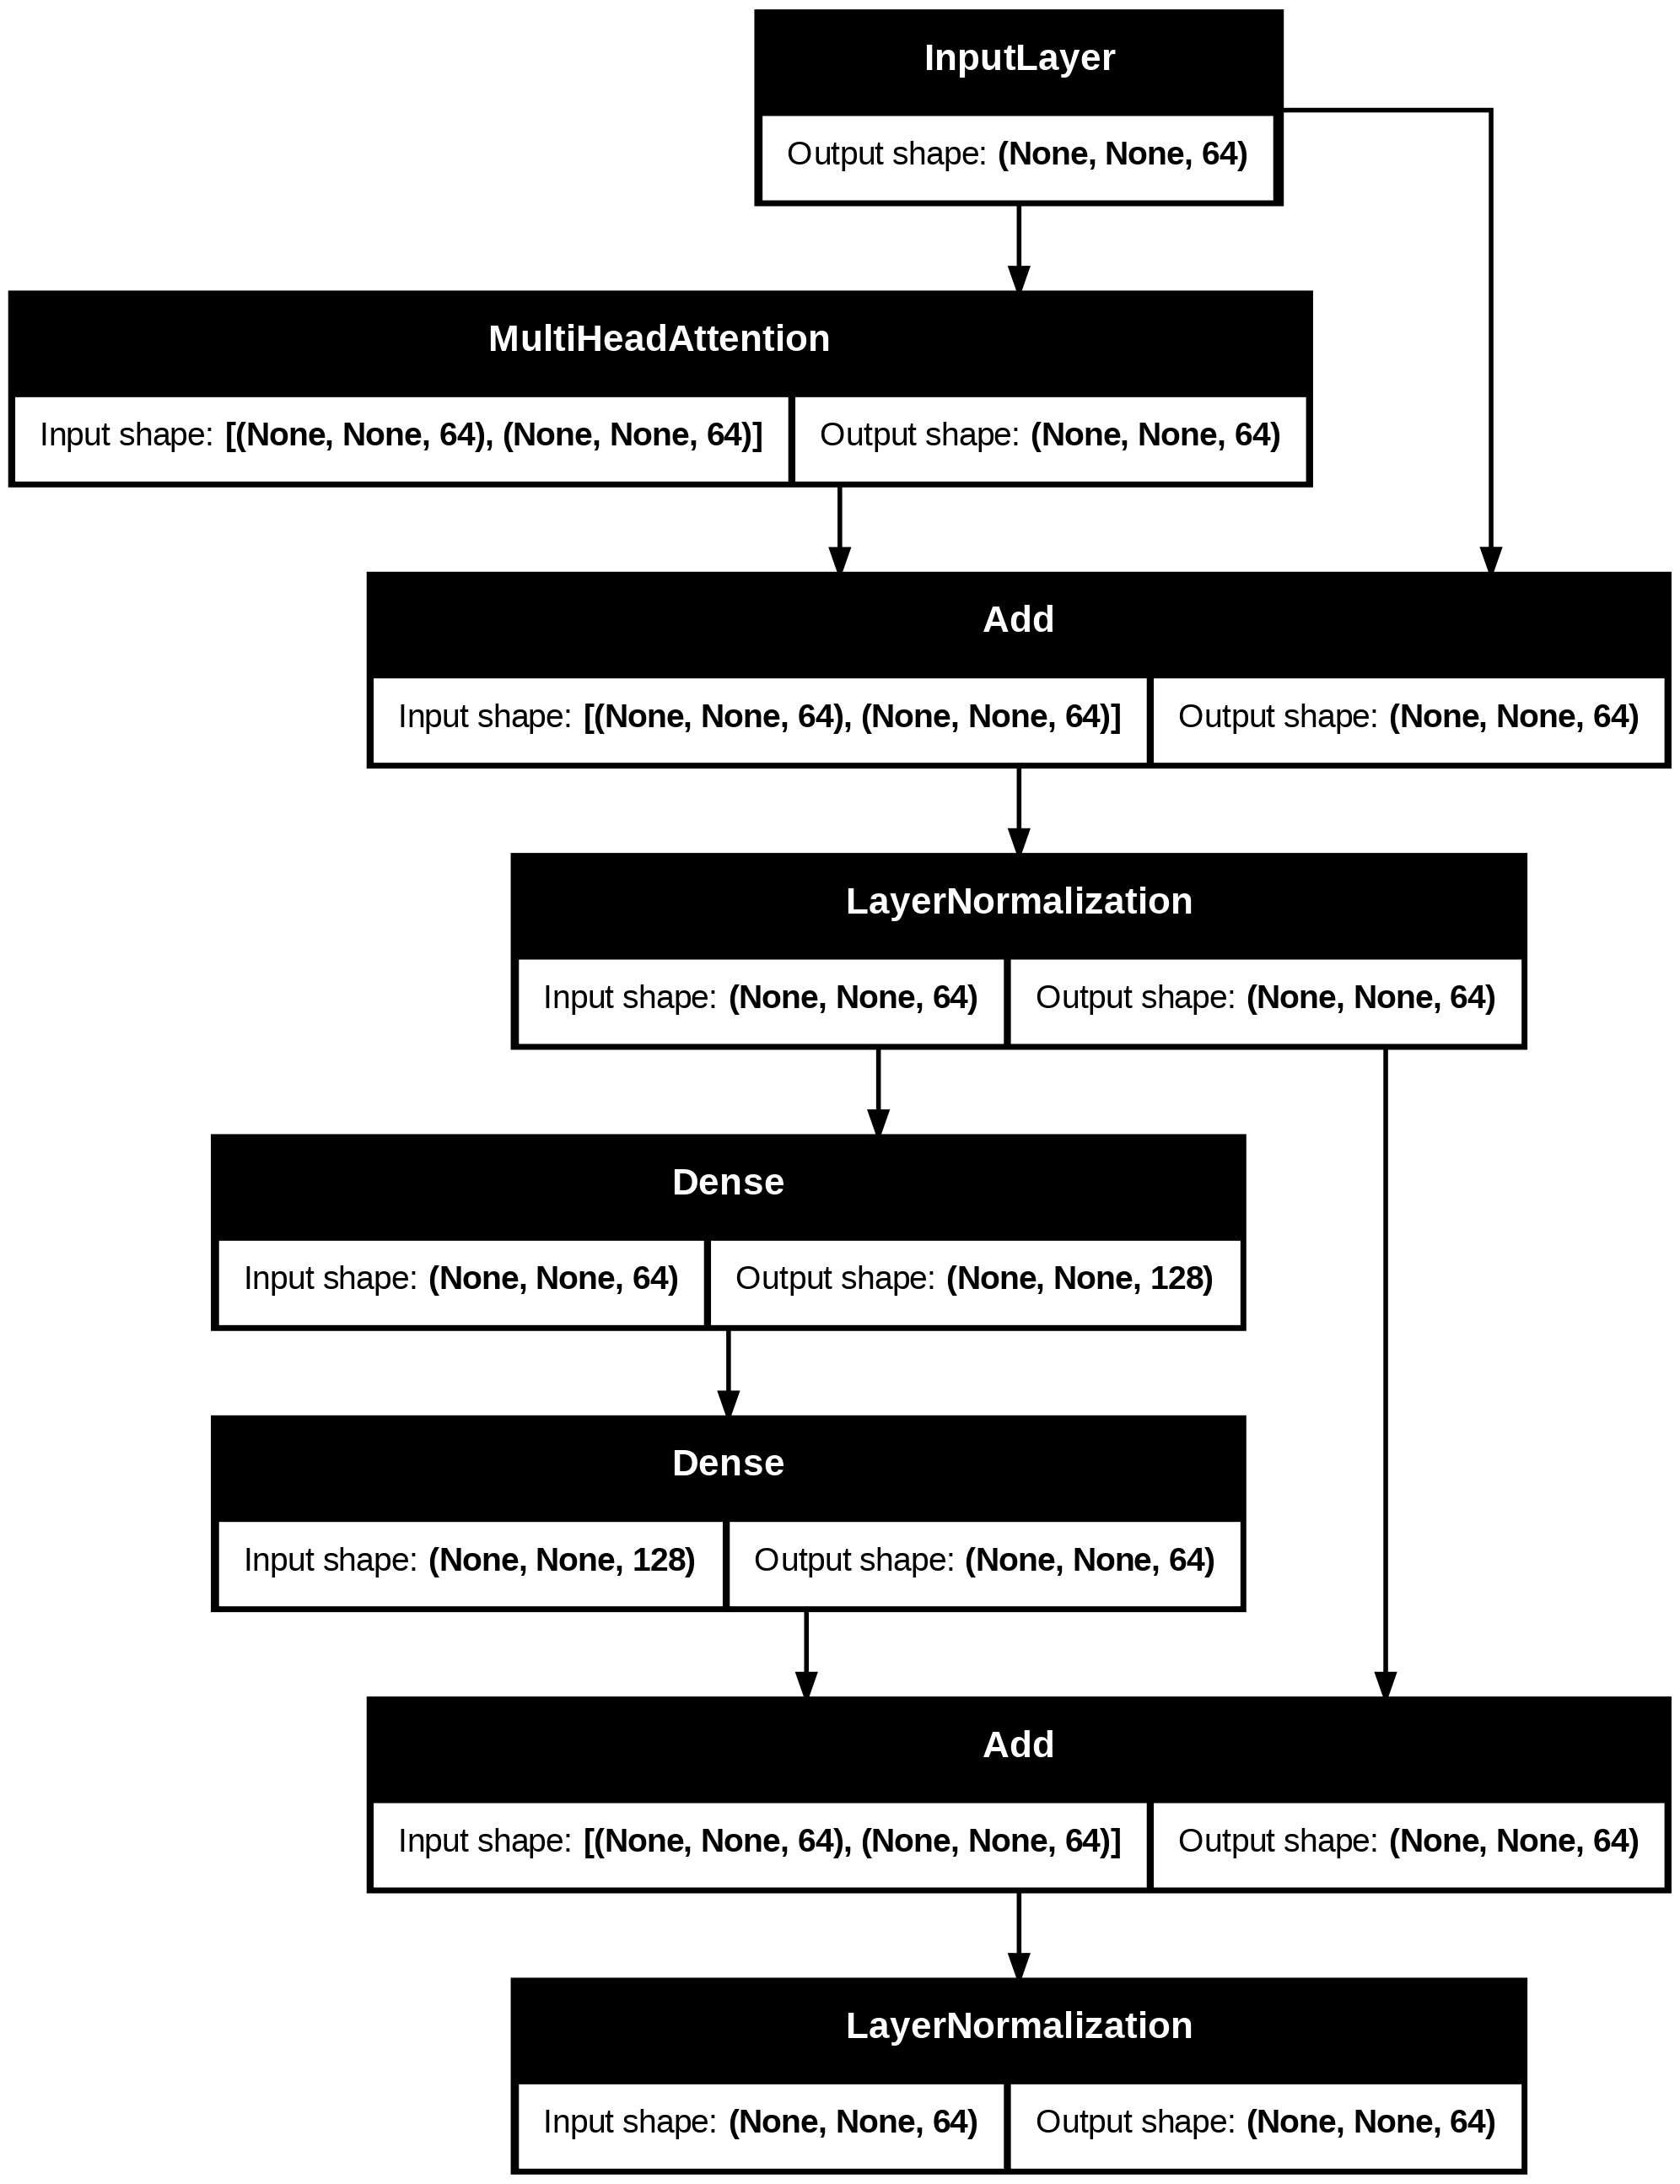

In [4]:
# Define a simplified transformer encoder block
def transformer_encoder(input_dim,num_heads, ff_dim):
    input = Input(shape=(None, input_dim))

    # Multi-Head self attentions
    attention_outpuut = MultiHeadAttention(num_heads=num_heads, key_dim=input_dim)(input, input)
    attention_outpuut = Add()([input, attention_outpuut])
    attention_outpuut = LayerNormalization()(attention_outpuut)

    # Feed Forward nn
    ff_output = Dense(ff_dim, activation="relu")(attention_outpuut)
    ff_output = Dense(input_dim)(ff_output)

    outputs = Add()([attention_outpuut, ff_output])
    outputs = LayerNormalization()(outputs)
    return Model(input, outputs)

encoder_bloc = transformer_encoder(input_dim=64, num_heads=8,ff_dim=128)
plot_model(encoder_bloc, show_shapes= True,to_file="transformer_encoder.png")

In [7]:
from transformers import BertTokenizer , BertModel
# Load a pre-trained BERT Tokenizer and model

tokenizer  = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased")

text = "Transformers are powerful models for NLP tasks"
inputs = tokenizer(text, return_tensors='pt')
outputs = model(**inputs)

print("Hidden States Shape:",outputs.last_hidden_state.shape)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Hidden States Shape: torch.Size([1, 10, 768])


In [3]:
!pip install "transformers<5.0" "tensorflow<2.20" -q
from transformers import TFBertModel, BertTokenizer

tokenizer  = BertTokenizer.from_pretrained("bert-base-uncased")
model = TFBertModel.from_pretrained("bert-base-uncased")

text = "Transformers are powerful models for NLP tasks"
inputs = tokenizer(text, return_tensors='tf')
outputs = model(**inputs)

print("Hidden States Shape:",outputs.last_hidden_state.shape)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 53.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 32.5 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.1 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.1 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.19.1 which is incompatible.


ImportError: cannot import name 'TFBertModel' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)